# <h1>**Customer Churn Prediction using ANN and Random Forest with Hyperparameter tuning**</h1>

## 📄 Introduction
This notebook details the process of building a deep learning model (ANN) to predict customer churn in a telecom environment. The goal is to accurately identify customers likely to discontinue service, allowing the company to proactively intervene.

# Importing necessary libraries

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

# Deep Learning 
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

#Random Forest
from sklearn.ensemble import RandomForestClassifier

# Suppresses warning messages for cleaner output.
import warnings 
warnings.filterwarnings('ignore')

## Data Loading and Initial Exploration

###  Load Dataset

*Load the `customer_churn.csv` file and inspect the first few rows to understand the features and the target variable (`Churn`).*

In [3]:
df = pd.read_csv("customer_churn.csv")


In [4]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
917,4079-WWQQQ,Male,0,No,No,72,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),65.55,4807.45,No
4658,8455-HIRAQ,Female,0,No,No,8,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,44.45,369.3,No
1518,1925-GMVBW,Female,0,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),20.55,96.1,No
4270,2167-FQSTQ,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,92.40,6786.1,No
3726,1965-DDBWU,Male,0,No,No,16,Yes,Yes,Fiber optic,No,...,No,Yes,No,Yes,Month-to-month,Yes,Credit card (automatic),89.05,1448.6,Yes


| Column Name | Description |
| :--- | :--- |
| **customerID** | Unique identifier for each customer. |
| **gender** | Customer's gender (Male/Female). |
| **SeniorCitizen** | Whether the customer is a senior citizen (1 for Yes, 0 for No). |
| **Partner** | Whether the customer is married/has a partner (Yes/No). |
| **Dependents** | Whether the customer has dependents (Yes/No). |
| **tenure** | Number of months the customer has been with the company. |
| **PhoneService** | Whether the customer has phone service (Yes/No). |
| **MultipleLines** | Whether the customer has multiple phone lines (Yes/No/No phone service). |
| **InternetService** | Customer's internet service provider (DSL/Fiber optic/No). |
| **OnlineSecurity** | Whether the customer has an online security service (Yes/No/No internet service). |
| **OnlineBackup** | Whether the customer has an online backup service (Yes/No/No internet service). |
| **DeviceProtection** | Whether the customer has device protection (Yes/No/No internet service). |
| **TechSupport** | Whether the customer subscribes to technical support (Yes/No/No internet service). |
| **StreamingTV** | Whether the customer streams TV (Yes/No/No internet service). |
| **StreamingMovies** | Whether the customer streams movies (Yes/No/No internet service). |
| **Contract** | The customer's contract term (Month-to-month/One year/Two year). |
| **PaperlessBilling** | Whether the customer uses paperless billing (Yes/No). |
| **PaymentMethod** | The method used for payment (e.g., Electronic check, Credit card). |
| **MonthlyCharges** | The amount charged to the customer monthly. |
| **TotalCharges** | The total amount charged to the customer over the contract period. |
| **Churn** | **The target variable:** Whether the customer left the company in the last month (Yes/No). |

**First of all, drop customerID column as it is of no use**

In [5]:
df.drop('customerID',axis='columns',inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
df.dtypes              #checking data types of column

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

**Quick glance at above makes me realize that TotalCharges should be float but it is an object. Let's check what's going on with  this column**

In [8]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

**it is string. Lets convert it to numbers**

## Data Preprocessing and Feature Engineering

### Handling Missing Values

*The dataset contains a few missing values in the `TotalCharges` column, which we will handle by dropping the rows.*

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [10]:
df.dropna(subset=['TotalCharges'], inplace=True)

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

**Data Visualization**

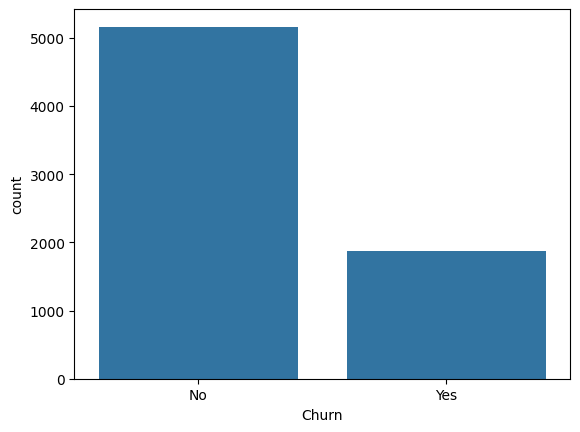

In [13]:
sns.countplot(x='Churn', data=df)
plt.show()

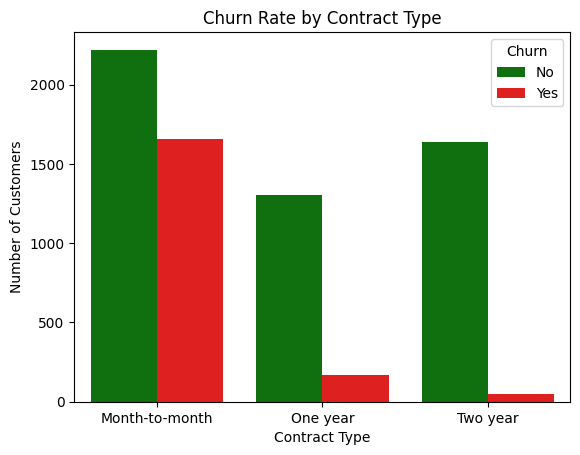

In [14]:
sns.countplot(x='Contract',hue='Churn',palette=['green','red'],data=df)
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

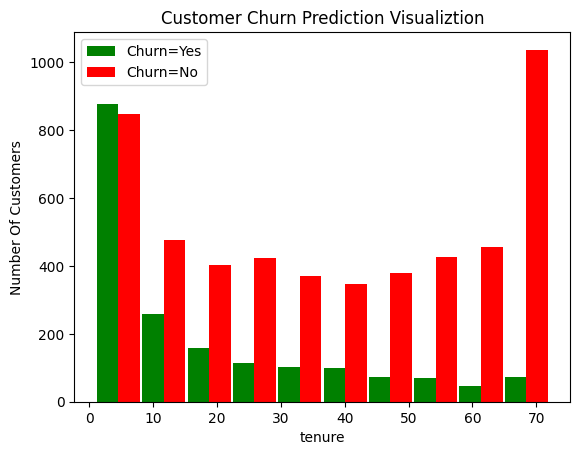

In [15]:
tenure_churn_no=df[df['Churn']=='No'].tenure
tenure_churn_yes=df[df['Churn']=='Yes'].tenure
plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()
plt.xlabel("tenure")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")
plt.show()

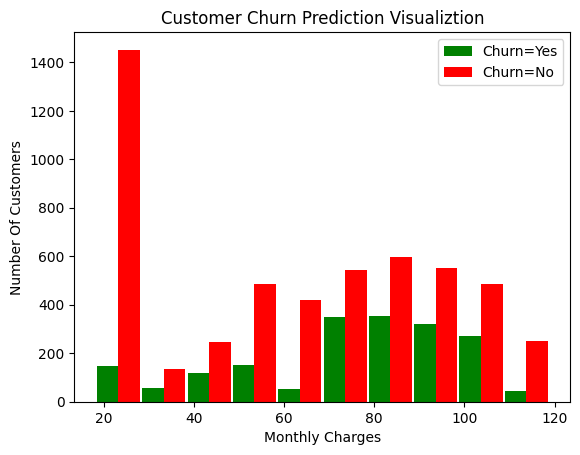

In [16]:
mc_churn_no = df[df.Churn=='No'].MonthlyCharges      
mc_churn_yes = df[df.Churn=='Yes'].MonthlyCharges      
plt.hist([mc_churn_yes, mc_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])
plt.legend()
plt.xlabel("Monthly Charges")
plt.ylabel("Number Of Customers")
plt.title("Customer Churn Prediction Visualiztion")
plt.show()

**Many of the columns are yes, no etc. Let's print unique values in object columns to see data values**

In [17]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}') 

In [18]:
print_unique_col_values(df)

gender: ['Female' 'Male']
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: ['No' 'Yes']


**Some of the columns have no internet service or no phone service, that can be replaced with a simple No**

In [19]:
df.replace('No phone service','No',inplace=True)
df.replace('No internet service','No',inplace=True)

In [20]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']

**Convert Yes and No to 1 or 0**

In [21]:
for col in yes_no_columns:
    df[col].replace({'Yes': 1,'No': 0},inplace=True)

In [22]:
df['gender'].replace({'Female':1,'Male':0},inplace=True)

**One hot encoding for categorical columns**

In [23]:
df= pd.get_dummies(data=df, columns=['InternetService','Contract','PaymentMethod'])

In [24]:
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
InternetService_DSL                           bool
InternetService_Fiber optic                   bool
InternetService_No             

***Feature Scaling***

In [25]:
from sklearn.preprocessing import MinMaxScaler

In [26]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

In [61]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**Train test split**

In [27]:
x=df.drop("Churn",axis=1)

In [28]:
y=df[["Churn"]]

In [29]:
from sklearn.model_selection import train_test_split

In [30]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [31]:
X_train.shape

(5625, 26)

In [32]:
X_test.shape

(1407, 26)

In [33]:
y_train.shape

(5625, 1)

In [34]:
y_test.shape

(1407, 1)

**ANN Model**

In [35]:
model=Sequential()
model.add(Dense(10,activation='relu',input_dim=26))
model.add(Dense(5,activation='relu',input_dim=26))
model.add(Dense(1,activation='sigmoid'))

In [36]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [37]:
history=model.fit(X_train,y_train,epochs=25,validation_split=0.2)

Epoch 1/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7371 - loss: 0.5738 - val_accuracy: 0.7218 - val_loss: 0.5176
Epoch 2/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7373 - loss: 0.4751 - val_accuracy: 0.7218 - val_loss: 0.4484
Epoch 3/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7442 - loss: 0.4465 - val_accuracy: 0.7600 - val_loss: 0.4310
Epoch 4/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7802 - loss: 0.4388 - val_accuracy: 0.7902 - val_loss: 0.4243
Epoch 5/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7896 - loss: 0.4348 - val_accuracy: 0.7982 - val_loss: 0.4210
Epoch 6/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7931 - loss: 0.4319 - val_accuracy: 0.8089 - val_loss: 0.4190
Epoch 7/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7969 - loss: 0.4290 - val_accuracy: 0.8071 - val_loss: 0.4169
Epoch 8/25
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7973 - loss: 0.4277 - val_accuracy:

In [38]:
model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7932 - loss: 0.4362


[0.4362485110759735, 0.7931769490242004]

In [39]:
yp = model.predict(X_test)
yp[:5]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


array([[0.00704821],
       [0.14160225],
       [0.66941833],
       [0.10634273],
       [0.32063717]], dtype=float32)

In [40]:
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [41]:
y_pred[:10]

[0, 0, 1, 0, 0, 0, 0, 1, 0, 0]

In [42]:
y_test[:10]

,Churn
2481,0
6784,0
6125,1
3052,0
4099,0
3223,0
3774,0
3469,0
3420,0
1196,0


***Model evaluation***

In [43]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407



In [44]:
from sklearn.metrics import accuracy_score

In [45]:
ann_accuracy=accuracy_score(y_test,y_pred)

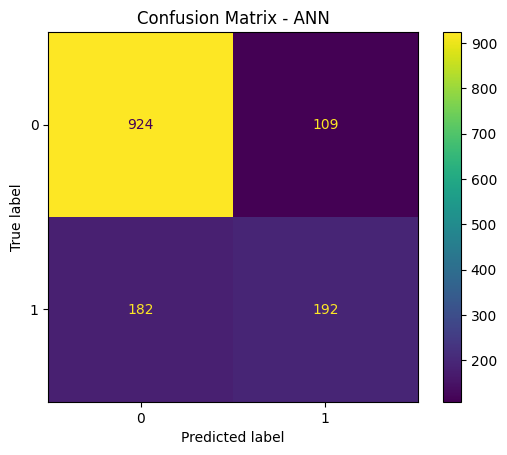

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - ANN")
plt.show()

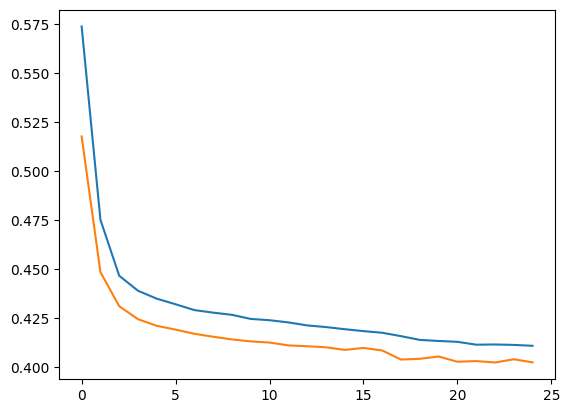

In [47]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

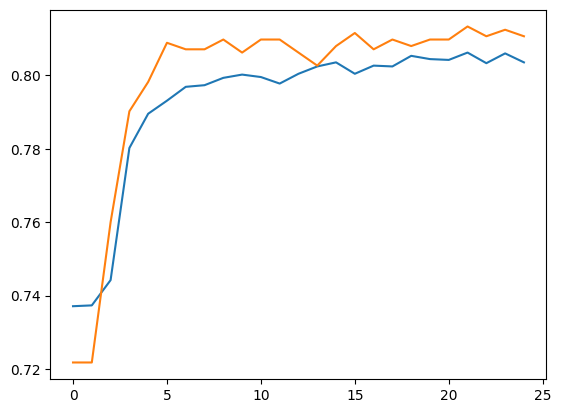

In [48]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])


**RANDOM FOREST MODEL**


In [49]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.7818052594171997
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



***Hyperparameter Tuning***

In [50]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train, y_train)
print("Best Parameters:", grid.best_params_)
best_rf = grid.best_estimator_

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [51]:
tuned_pred = best_rf.predict(X_test)

print("Tuned RF Accuracy:", accuracy_score(y_test, tuned_pred))
print(classification_report(y_test, tuned_pred))

Tuned RF Accuracy: 0.7938877043354655
              precision    recall  f1-score   support

           0       0.83      0.90      0.87      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



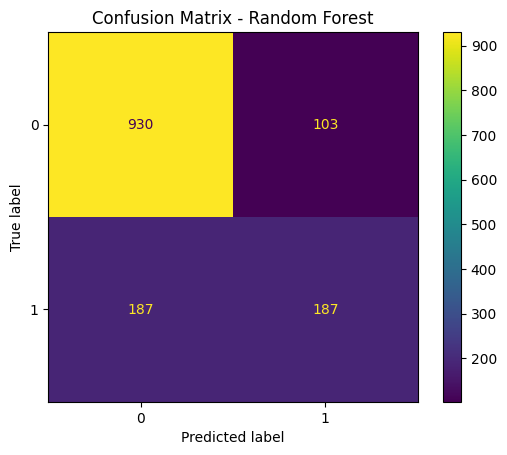

In [52]:
ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("Confusion Matrix - Random Forest")
plt.show()

***Model Comparison***

In [53]:
print(f"ANN Accuracy: {ann_accuracy}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred)}")
print(f"Tuned RF Accuracy: {accuracy_score(y_test, tuned_pred)}")

ANN Accuracy: 0.7931769722814499
Random Forest Accuracy: 0.7818052594171997
Tuned RF Accuracy: 0.7938877043354655


In [54]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import joblib
joblib.dump(best_rf, "churn_model.pkl")

['churn_model.pkl']

In [59]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [60]:
# Get some churn cases from dataset
df[df['Churn'] == 1].head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
2,0,0,0,0,0.014085,1,0,1,1,0,...,True,False,False,True,False,False,False,False,False,True
4,1,0,0,0,0.014085,1,0,0,0,0,...,False,True,False,True,False,False,False,False,True,False
5,1,0,0,0,0.098592,1,1,0,0,1,...,False,True,False,True,False,False,False,False,True,False
8,1,0,1,0,0.380282,1,1,0,0,1,...,False,True,False,True,False,False,False,False,True,False
13,0,0,0,0,0.676056,1,1,0,1,1,...,False,True,False,True,False,False,True,False,False,False


**Conclusion**